# Assignment 1 - Exercise Setup
This notebook contains the necessary code setup for the accompanying exercises. 

# 1. Coordinate Descent

In [2]:
import numpy as np
def argmin_x1(x):
    return (3 * x[1] + 2 * x[2] - 1) / 2.0

def argmin_x2(x):
    return (x[0] + 2 * x[2] + 5) / 6.0

def argmin_x3(x):
    return (x[0] + 3 * x[1] - 4) / 4.0

def f(x):
    term1 = np.exp(x[0] - 3*x[1] + 3)
    term2 = np.exp(3*x[1] - 2*x[2] - 2)
    term3 = np.exp(2*x[2] - x[0] + 2)
    return term1 + term2 + term3

def coordinate_descent(f, argmin, x0, max_iter=100, verbose=False):
    x_t = np.array(x0, dtype=float)
    
    for i in range(max_iter):
        # Update all coordinates in order
        for j in range(len(x_t)):
            x_t[j] = argmin[j](x_t)
             
        if verbose:
            print(f"Iteration {i+1}: x = {x_t}, f(x) = {f(x_t):.6f}")
            
    f_xt = f(x_t)
        
    return x_t, f_xt

In [4]:
argmin_funcs = [argmin_x1, argmin_x2, argmin_x3]
    
x_initial = [1, 20, 5]

x_opt, f_opt = coordinate_descent(f, argmin_funcs, x_initial, max_iter=25, verbose=True)

print("\n--- Final Results ---")
print(f"Optimized Coordinates: {x_opt}")
print(f"Minimum Function Value: {f_opt:.6f}")

Iteration 1: x = [34.5     8.25   13.8125], f(x) = 344551.911408
Iteration 2: x = [25.6875     9.71875   12.7109375], f(x) = 11.956556
Iteration 3: x = [26.7890625   9.53515625 12.84863281], f(x) = 8.225816
Iteration 4: x = [26.65136719  9.55810547 12.8314209 ], f(x) = 8.155915
Iteration 5: x = [26.6685791   9.55523682 12.83357239], f(x) = 8.154862
Iteration 6: x = [26.66642761  9.5555954  12.83330345], f(x) = 8.154846
Iteration 7: x = [26.66669655  9.55555058 12.83333707], f(x) = 8.154845
Iteration 8: x = [26.66666293  9.55555618 12.83333287], f(x) = 8.154845
Iteration 9: x = [26.66666713  9.55555548 12.83333339], f(x) = 8.154845
Iteration 10: x = [26.66666661  9.55555557 12.83333333], f(x) = 8.154845
Iteration 11: x = [26.66666667  9.55555555 12.83333333], f(x) = 8.154845
Iteration 12: x = [26.66666667  9.55555556 12.83333333], f(x) = 8.154845
Iteration 13: x = [26.66666667  9.55555556 12.83333333], f(x) = 8.154845
Iteration 14: x = [26.66666667  9.55555556 12.83333333], f(x) = 8.154

# 2. Gradient Descent

In [5]:
import math 
def f(x):
    u = x[0]
    v = x[1]
    return (u**2 + v - 11)**2 + (u + v**2 - 7)**2

def grad_f(x):
    u = x[0]
    v = x[1]
    du = 4 * u * (u**2 + v - 11) + 2 * (u + v**2 - 7)
    dv = 2 * (u**2 + v - 11) + 4 * v * (u + v**2 - 7)
    return [du, dv]

def gradient_descent(f, grad_f, eta, u0, v0, max_iter=100) -> tuple[list, list]:
    x = [float(u0), float(v0)]
    
    path = [(x[0], x[1])]
    f_vals = [f(x)]
    
    for t in range(1, max_iter + 1):
        step_size = eta(t)
        grad = grad_f(x)
        
        # Apply update rule
        x[0] = x[0] - step_size * grad[0]
        x[1] = x[1] - step_size * grad[1]
        
        path.append((x[0], x[1]))
        f_vals.append(f(x))
        
    return path, f_vals

def eta_const(t,c=1e-3) -> float:
    return float(c)

def eta_sqrt(t,c=1e-3) -> float:
    return float(c / math.sqrt(t + 1))

def eta_multistep(t, milestones=[20, 50], c=1e-4, eta_init=1e-3) -> float:
    eta = eta_init
    for m in milestones:
        if t >= m:
            eta *= c
    return float(eta)

In [ ]:
u0, v0 = 4, -5

# 2a
path_const, f_const = gradient_descent(f, grad_f, eta_const, u0, v0)
print("2a: Constant Step Size")
print(f"f(u_100, v_100): {f_const[100]:.6f}")
print(f"min f(u_t, v_t): {min(f_const[1:]):.6f}\n")

# 2b 
path_sqrt, f_sqrt = gradient_descent(f, grad_f, eta_sqrt, u0, v0)
print("2b: Decreasing Step Size")
print(f"f(u_100, v_100): {f_sqrt[100]:.6f}")
print(f"min f(u_t, v_t): {min(f_sqrt[1:]):.6f}\n")

# 2c
eta_multi_test = lambda t: eta_multistep(t, milestones=[30, 80, 100], c=1e-3, eta_init=1e-3)
path_multi, f_multi = gradient_descent(f, grad_f, eta_multi_test, u0, v0)

print("2c: Multi-Step Schedule")
print(f"f(u_100, v_100): {f_multi[100]:.6f}")
print(f"min f(u_t, v_t): {min(f_multi[1:]):.6f}\n")

# 2d
points = [
    ("p1", -4, 0),
    ("p2", 0, 0),
    ("p3", 4, 0),
    ("p4", 0, 4),
    ("p5", 5, 5)
]

print("2d: Initialization")
for name, u_init, v_init in points:
    path, f_vals = gradient_descent(f, grad_f, eta_const, u_init, v_init)
    
    # Extract final point and value
    u_final, v_final = path[100]
    f_final = f_vals[100]
    
    print(f"{name} -> u: {u_final:.6f}, v: {v_final:.6f}, f_final: {f_final:.6f}")

=== 2a: Constant Step Size ===
f(u_100, v_100): 0.028936
min f(u_t, v_t): 0.028936

=== 2b: Decreasing Step Size ===
f(u_100, v_100): 14.481428
min f(u_t, v_t): 14.481428

=== 2c: Multi-Step Schedule ===
f(u_100, v_100): 4.034191
min f(u_t, v_t): 4.034191

=== 2d: Initialization ===
p1 -> u: -3.152769, v: -0.724579, f_final: 95.878543
p2 -> u: 2.908593, v: 2.093055, f_final: 0.283629
p3 -> u: 3.450357, v: -0.481676, f_final: 11.185851
p4 -> u: -2.367112, v: 3.099995, f_final: 5.334203
p5 -> u: 2.982228, v: 2.041376, f_final: 0.026551


# 3. Polynomial Regression

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load the dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
# The description of this dataset applies to the data provided over Canvas
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [2]:
import pandas as pd

# Adapt path
df = pd.read_csv("california_housing_with_split.csv")

train = df[df["split"] == "train"]
test  = df[df["split"] == "test"]

X_train = train.drop(columns=["MedHouseVal", "split"])
y_train = train["MedHouseVal"]

X_test = test.drop(columns=["MedHouseVal", "split"])
y_test = test["MedHouseVal"]

In [3]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)


# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)
mse_lin = mean_squared_error(y_test, y_pred_lin)

# Map coefficients to their feature names
coef_lin = pd.Series(lin_reg.coef_, index=X_train_scaled.columns)

print("Linear Model")
print(f"Beta MedInc:      {coef_lin['MedInc']:.6f}")
print(f"Beta AveBedrms:   {coef_lin['AveBedrms']:.6f}")
print(f"Beta HouseAge:    {coef_lin['HouseAge']:.6f}")
print(f"MSE Test:         {mse_lin:.6f}\n")


# Polynomial Regression
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_feature_names = poly.get_feature_names_out(X_train_scaled.columns)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

y_pred_poly = poly_reg.predict(X_test_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)

coef_poly = pd.Series(poly_reg.coef_, index=poly_feature_names)

print("Polynomial Model (Degree 2)")
print(f"Beta MedInc:                {coef_poly['MedInc']:.6f}")
print(f"Beta MedInc*AveBedrms:      {coef_poly['MedInc AveBedrms']:.6f}")
print(f"Beta HouseAge*AveBedrms:    {coef_poly['HouseAge AveBedrms']:.6f}")
print(f"MSE Test:                   {mse_poly:.6f}")

Linear Model
Beta MedInc:      0.854383
Beta AveBedrms:   0.339259
Beta HouseAge:    0.122546
MSE Test:         0.555892

Polynomial Model (Degree 2)
Beta MedInc:                0.935940
Beta MedInc*AveBedrms:      -0.120152
Beta HouseAge*AveBedrms:    0.052345
MSE Test:                   0.464302


To solve this part of the exercise and verify our results, we will approach the problem using two methods: first, utilizing `scikit-learn`'s built-in regressor, and second, constructing the closed-form solution manually using `numpy`. We then compare the results from both methods.

##### Method 1: Using `scikit-learn`
To correctly implement `scikit-learn`'s `Ridge` model, we must adjust a few parameters to match the exercise's specific objective function: $J(\beta) = \frac{1}{n} \|y - X\beta\|^2 + \lambda\|\beta\|^2$.
* **Setting the `alpha` parameter:** The `scikit-learn` implementation minimizes the standard Residual Sum of Squares (RSS) penalized by $\alpha$: $\|y - X\beta\|^2 + \alpha\|\beta\|^2$. To mathematically equate this to the exercise's objective, we must scale the regularization parameter by the number of training samples ($n$). Therefore, we calculate and set $\alpha = n\lambda$.
* **Setting the `solver` parameter:** The lecture slides demonstrate the invertibility and uniqueness of the minimizer using Singular Value Decomposition. To ensure `scikit-learn` follows this exact mathematical procedure, we explicitly set `solver='svd'`.

##### Method 2: Manual Closed-Form Solution
We will manually compute the parameter weights using `numpy` based on the closed-form formula derived from the objective function. To perfectly match the scikit-learn's default behavior of not applying the $L_2$ penalty to the intercept term, we will first center the $X$ and $y$ data before applying the following formula:
$$\beta = (X^TX + n\lambda I)^{-1}X^Ty$$

In [11]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

lmbda = 0.001
n_samples = X_train_poly.shape[0]

alpha_sklearn = n_samples * lmbda

ridge_reg = Ridge(alpha=alpha_sklearn, solver='svd')
ridge_reg.fit(X_train_poly, y_train)

y_pred_ridge = ridge_reg.predict(X_test_poly)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

coef_ridge = pd.Series(ridge_reg.coef_, index=poly_feature_names)

print("Scikit-Learn Ridge Polynomial Model (Degree 2)")
print(f"Beta MedInc:                {coef_ridge['MedInc']:.6f}")
print(f"Beta MedInc*AveBedrms:      {coef_ridge['MedInc AveBedrms']:.6f}")
print(f"Beta HouseAge*AveBedrms:    {coef_ridge['HouseAge AveBedrms']:.6f}")
print(f"MSE Test:                   {mse_ridge:.6f}")

Scikit-Learn Ridge Polynomial Model (Degree 2)
Beta MedInc:                0.943703
Beta MedInc*AveBedrms:      -0.115015
Beta HouseAge*AveBedrms:    0.060710
MSE Test:                   0.445156


In [12]:
import numpy as np
import pandas as pd

lmbda = 0.001
n_samples = X_train_poly.shape[0]
alpha = n_samples * lmbda

# Center the data to avoid penalizing the intercept 
X_mean = X_train_poly.mean(axis=0)
y_mean = y_train.mean()

X_centered = X_train_poly - X_mean
y_centered = y_train - y_mean

# Create the Identity Matrix (I)
p = X_centered.shape[1]
I = np.eye(p)

# Compute the components of the closed-form formula
XTX = X_centered.T @ X_centered
XTy = X_centered.T @ y_centered

matrix_to_invert = XTX + (alpha * I)

# Solve for Beta
beta_closed_form = np.linalg.solve(matrix_to_invert, XTy)

coef_manual = pd.Series(beta_closed_form, index=poly_feature_names)

print("Closed-Form Manual Implementation")
print(f"Beta MedInc:                {coef_manual['MedInc']:.6f}")
print(f"Beta MedInc*AveBedrms:      {coef_manual['MedInc AveBedrms']:.6f}")
print(f"Beta HouseAge*AveBedrms:    {coef_manual['HouseAge AveBedrms']:.6f}")

Closed-Form Manual Implementation
Beta MedInc:                0.943703
Beta MedInc*AveBedrms:      -0.115015
Beta HouseAge*AveBedrms:    0.060710


# 5. Naive Bayes

In [ ]:
from sklearn.datasets import fetch_20newsgroups
categories = ['sci.space', 'misc.forsale', 'comp.graphics', 'rec.sport.hockey']
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)

print(train.DESCR)

The classes are indicated categorically with indices from zero to two by the target vector. The target names tell us which index belongs to which class.

In [ ]:
y_train = train.target
y_train

In [ ]:
train.target_names

We represent the documents in a bag of word format. That is, we create a data matrix ``D`` such that ``D[j,i]=1`` if the j-th document contains the i-th feature (word), and ``D[j,i]=0`` otherwise. 

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
vectorizer = CountVectorizer(stop_words="english", min_df=5,token_pattern=r"[^\W\d_]+", binary=True)
D = vectorizer.fit_transform(train.data)
D_test = vectorizer.transform(test.data)

We get the allocation of feature indices to words by the following array, containing the vocabulary.

In [ ]:
vectorizer.get_feature_names_out()

For example, the word `zubov` has the index 7383.

In [ ]:
np.where(vectorizer.get_feature_names_out() == 'zubov')[0]

# 6. Lasso vs Ridge Regression

In [1]:
import pandas as pd
df = pd.read_csv("METABRIC_RNA_Mutation.csv")
df_D = pd.concat([df['age_at_diagnosis'], df.iloc[:, 31:520]],axis=1)
D = df_D.to_numpy()
y = df['overall_survival_months'].to_numpy()

C:\Users\Bill\AppData\Local\Temp\ipykernel_1548\1672240696.py:2: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("METABRIC_RNA_Mutation.csv")


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Create the Design Matrix X for affine basis functions
n_samples, p_features = D.shape
X = np.hstack([np.ones((n_samples, 1)), D])

def fit_ridge(X, y, lmbda):
    """
    Fits a ridge regression model without penalizing the bias term.
    Uses the adapted formula: beta = (X^T X + 2*n*lambda*D)^-1 X^T y
    """
    n, p = X.shape
    
    # Create the diagonal penalty matrix
    penalty_diag = np.eye(p)
    penalty_diag[0, 0] = 0 
    
    # Calculate components
    XTX = X.T @ X
    XTy = X.T @ y
    penalty_term = 2 * n * lmbda * penalty_diag
    
    # Solve for beta (using np.linalg.solve is more numerically stable than taking the inverse directly)
    beta = np.linalg.solve(XTX + penalty_term, XTy)
    return beta

def predict_ridge(X, beta):
    """
    Returns the predictions of the ridge regression model.
    """
    return X @ beta

c:\Users\Bill\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.898e+06, tolerance: 8.979e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\Bill\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.890e+05, tolerance: 8.690e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\Bill\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.274e+05, tolerance: 

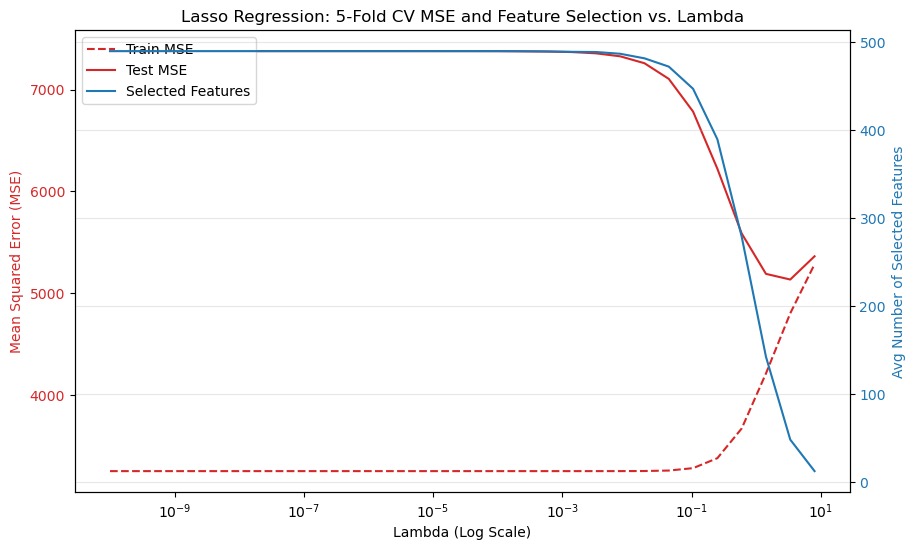

In [3]:
# Define the range of lambdas
lambdas = np.logspace(-10, np.log10(8), num=30)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

avg_train_mse = []
avg_test_mse = []
avg_selected_features = []

for lmbda in lambdas:
    fold_train_mse = []
    fold_test_mse = []
    fold_selected = []
    
    for train_idx, test_idx in kf.split(D):
        D_train, D_test = D[train_idx], D[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Initialize and fit Lasso
        lasso = Lasso(alpha=lmbda, fit_intercept=True, max_iter=5000)
        lasso.fit(D_train, y_train)
        
        # Predictions
        pred_train = lasso.predict(D_train)
        pred_test = lasso.predict(D_test)
        
        # MSE
        fold_train_mse.append(mean_squared_error(y_train, pred_train))
        fold_test_mse.append(mean_squared_error(y_test, pred_test))
        
        # Count selected features (|beta_s| > 10^-16)
        num_selected = np.sum(np.abs(lasso.coef_) > 1e-16)
        fold_selected.append(num_selected)
        
    # Average across the 5 folds
    avg_train_mse.append(np.mean(fold_train_mse))
    avg_test_mse.append(np.mean(fold_test_mse))
    avg_selected_features.append(np.mean(fold_selected))

# Plotting the Results
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSEs on the left y-axis
color = 'tab:red'
ax1.set_xlabel('Lambda (Log Scale)')
ax1.set_ylabel('Mean Squared Error (MSE)', color=color)
ax1.plot(lambdas, avg_train_mse, color=color, linestyle='--', label='Train MSE')
ax1.plot(lambdas, avg_test_mse, color=color, linestyle='-', label='Test MSE')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

# Plot the number of selected features
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Avg Number of Selected Features', color=color)  
ax2.plot(lambdas, avg_selected_features, color=color, linestyle='-', label='Selected Features')
ax2.tick_params(axis='y', labelcolor=color)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Lasso Regression: 5-Fold CV MSE and Feature Selection vs. Lambda')
plt.grid(True, alpha=0.3)
plt.show()

c:\Users\Bill\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.500e+06, tolerance: 8.979e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\Bill\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.448e+06, tolerance: 8.690e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\Bill\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.489e+06, tolerance: 

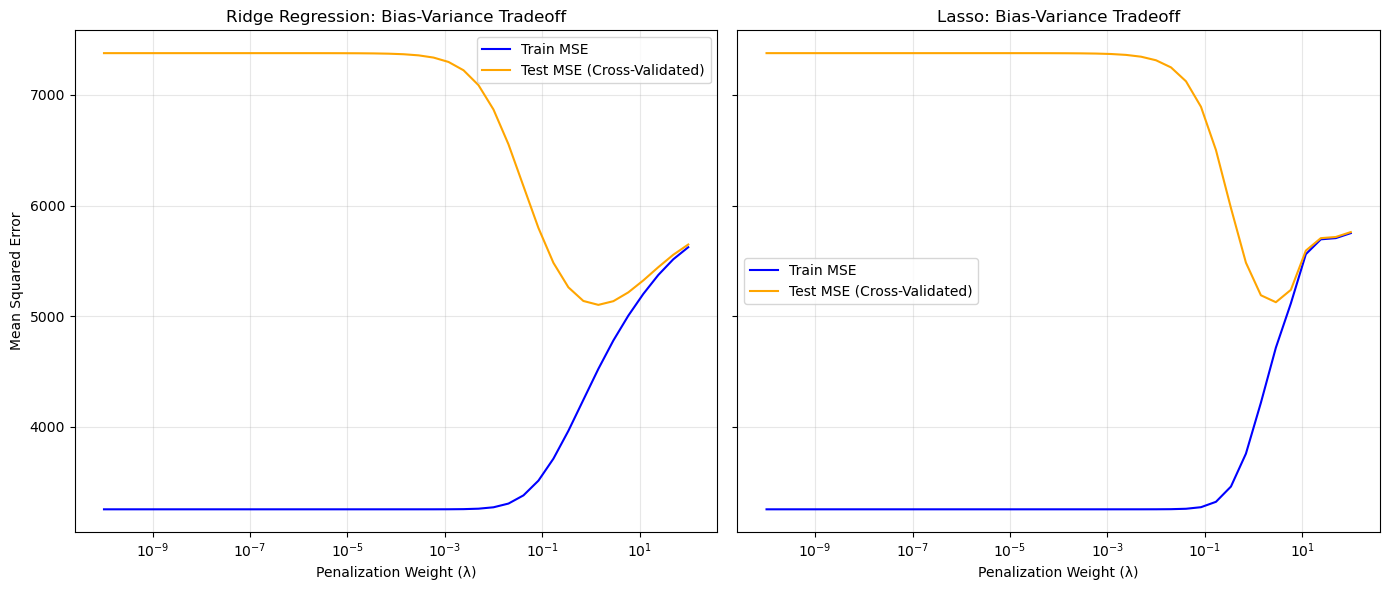

In [4]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lambdas = np.logspace(-10, 2, num=40) 

ridge_train_mse, ridge_test_mse = [], []
lasso_train_mse, lasso_test_mse = [], []

for lmbda in lambdas:
    r_train_fold, r_test_fold = [], []
    l_train_fold, l_test_fold = [], []
    
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        D_train, D_test = D[train_idx], D[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Ridge
        beta_ridge = fit_ridge(X_train, y_train, lmbda)
        r_train_fold.append(mean_squared_error(y_train, X_train @ beta_ridge))
        r_test_fold.append(mean_squared_error(y_test, X_test @ beta_ridge))
        
        # Lasso
        lasso = Lasso(alpha=lmbda, fit_intercept=True, max_iter=2000)
        lasso.fit(D_train, y_train)
        l_train_fold.append(mean_squared_error(y_train, lasso.predict(D_train)))
        l_test_fold.append(mean_squared_error(y_test, lasso.predict(D_test)))
        
    ridge_train_mse.append(np.mean(r_train_fold))
    ridge_test_mse.append(np.mean(r_test_fold))
    lasso_train_mse.append(np.mean(l_train_fold))
    lasso_test_mse.append(np.mean(l_test_fold))

# Pltting results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Ridge Plot
ax1.plot(lambdas, ridge_train_mse, label='Train MSE', color='blue')
ax1.plot(lambdas, ridge_test_mse, label='Test MSE (Cross-Validated)', color='orange')
ax1.set_xscale('log')
ax1.set_xlabel('Penalization Weight (λ)')
ax1.set_ylabel('Mean Squared Error')
ax1.set_title('Ridge Regression: Bias-Variance Tradeoff')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Lasso Plot
ax2.plot(lambdas, lasso_train_mse, label='Train MSE', color='blue')
ax2.plot(lambdas, lasso_test_mse, label='Test MSE (Cross-Validated)', color='orange')
ax2.set_xscale('log')
ax2.set_xlabel('Penalization Weight (λ)')
ax2.set_title('Lasso: Bias-Variance Tradeoff')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bias_variance_tradeoff_plots.png", dpi=300) # Save for uploading
plt.show()

c:\Users\Bill\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.402e+06, tolerance: 1.109e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Bill\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.402e+06, tolerance: 1.109e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Bill\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.402e+06, tolerance: 

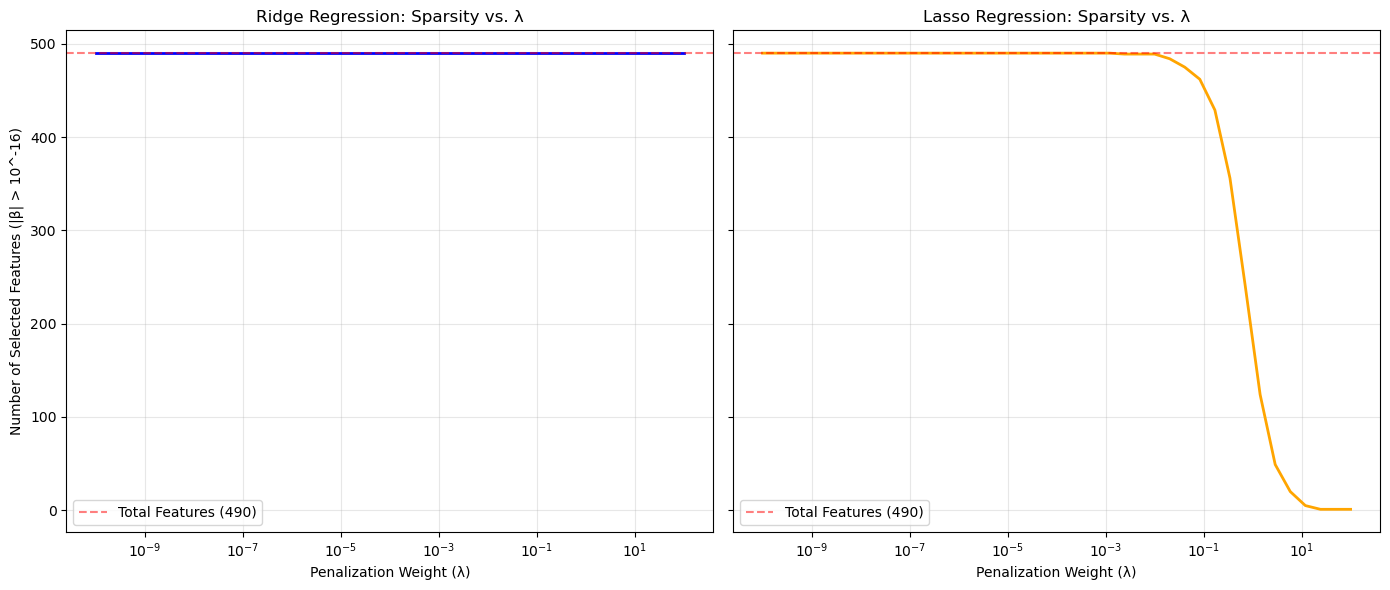

In [6]:

lambdas = np.logspace(-10, 2, num=40) 

ridge_selected_features = []
lasso_selected_features = []

for lmbda in lambdas:
    # Ridge
    beta_ridge = fit_ridge(X, y, lmbda)
    ridge_count = np.sum(np.abs(beta_ridge[1:]) > 1e-16)
    ridge_selected_features.append(ridge_count)
    
    # Lasso
    lasso = Lasso(alpha=lmbda, fit_intercept=True, max_iter=2000)
    lasso.fit(D, y)
   
    lasso_count = np.sum(np.abs(lasso.coef_) > 1e-16)
    lasso_selected_features.append(lasso_count)

# Plotting the Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Ridge Plot
ax1.plot(lambdas, ridge_selected_features, color='blue', linewidth=2)
ax1.axhline(y=p_features, color='red', linestyle='--', alpha=0.5, label=f'Total Features ({p_features})')
ax1.set_xscale('log')
ax1.set_xlabel('Penalization Weight (λ)')
ax1.set_ylabel('Number of Selected Features (|β| > 10^-16)')
ax1.set_title('Ridge Regression: Sparsity vs. λ')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Lasso Plot
ax2.plot(lambdas, lasso_selected_features, color='orange', linewidth=2)
ax2.axhline(y=p_features, color='red', linestyle='--', alpha=0.5, label=f'Total Features ({p_features})')
ax2.set_xscale('log')
ax2.set_xlabel('Penalization Weight (λ)')
ax2.set_title('Lasso Regression: Sparsity vs. λ')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sparsity_plots.png", dpi=300)
plt.show()